# **Step 1: Setup and Unzip Archive Folder**

In [2]:
import os

# Define paths for Kaggle input dataset
base_path = '/kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload'

train_image_path = os.path.join(base_path, 'images/train')
val_image_path = os.path.join(base_path, 'images/val')

train_label_path = os.path.join(base_path, 'labels/train')
val_label_path = os.path.join(base_path, 'labels/val')

# Print paths to verify
print(f"Train images path: {train_image_path}")
print(f"Validation images path: {val_image_path}")
print(f"Train labels path: {train_label_path}")
print(f"Validation labels path: {val_label_path}")


Train images path: /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Validation images path: /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/val
Train labels path: /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/labels/train
Validation labels path: /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/labels/val


# **Step 2: Preprocessing with Progress Prints**

In [3]:
from PIL import Image
import os

# Convert images to JPG if necessary and provide progress feedback
def convert_images_to_jpg(folder_path):
    total_files = len(os.listdir(folder_path))
    for idx, filename in enumerate(os.listdir(folder_path)):
        if not filename.endswith('.jpg'):
            img = Image.open(os.path.join(folder_path, filename))
            img.convert('RGB').save(os.path.join(folder_path, os.path.splitext(filename)[0] + '.jpg'), 'JPEG')
            os.remove(os.path.join(folder_path, filename))  # Remove old file
        if idx % 5000 == 0:  # Print progress every 5000 images
            print(f"Processed {idx}/{total_files} images in {folder_path}")

print("Converting train images...")
convert_images_to_jpg(train_image_path)

print("Converting validation images...")
convert_images_to_jpg(val_image_path)

# Verify annotations format with progress prints
def check_labels(label_folder):
    total_labels = len(os.listdir(label_folder))
    for idx, label_file in enumerate(os.listdir(label_folder)):
        with open(os.path.join(label_folder, label_file), 'r') as file:
            for line in file.readlines():
                values = line.strip().split(' ')
                assert len(values) == 5, f"Incorrect label format in {label_file}"
        if idx % 5000 == 0:  # Print progress every 5000 labels
            print(f"Verified {idx}/{total_labels} label files in {label_folder}")

print("Verifying train labels...")
check_labels(train_label_path)

print("Verifying validation labels...")
check_labels(val_label_path)

print("Data preprocessing complete!")


Converting train images...
Processed 0/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 5000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 10000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 15000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 20000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 25000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 30000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 35000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
Processed 40000/83791 images in /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/tra

# **Step 3: Install YOLOv5**

In [4]:
import os
import subprocess

# Change to /kaggle/working directory
os.chdir('/kaggle/working')

# Verify the change by getting the current working directory
print("Current path:", os.getcwd())

# Check if the YOLOv5 directory exists in the current working directory
if os.path.isdir('yolov5'):
    print("YOLOv5 directory exists. Skipping clone...")
else:
    print("YOLOv5 directory does not exist. Proceeding to clone...")
    # Clone the YOLOv5 repository again
    subprocess.run(['git', 'clone', 'https://github.com/ultralytics/yolov5'])

# Change the current working directory to yolov5
os.chdir('yolov5')

# Install the required dependencies if they're not already installed
try:
    import torch
    import torchvision
    print("PyTorch and torchvision are already installed.")
except ImportError:
    print("Installing PyTorch and torchvision...")
    !pip install torch torchvision

# Install YOLOv5 dependencies from requirements.txt
try:
    import yaml
    print("YOLOv5 requirements already installed.")
except ImportError:
    print("Installing YOLOv5 dependencies from requirements.txt...")
    !pip install -r requirements.txt

Current path: /kaggle/working
YOLOv5 directory does not exist. Proceeding to clone...


Cloning into 'yolov5'...


PyTorch and torchvision are already installed.
YOLOv5 requirements already installed.


# **Step 4: Training YOLOv5**

In [5]:
# Create the folder named 'Detrac'
!mkdir /kaggle/working/Detrac_File
# Create the detrac.yaml file with the required structure
detrac_yaml_content = """
train: /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/train
val: /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/images/val
nc: 4 # Number of classes
names:
  0: "class0"
  1: "class1"
  2: "class2"
  3: "class3"
"""

# Write the content to a new detrac.yaml file in the Detrac folder
with open('/kaggle/working/Detrac_File/detrac.yaml', 'w') as f:
    f.write(detrac_yaml_content)

print("detrac.yaml created successfully!")


detrac.yaml created successfully!


#  **5. Train the Model**

In [7]:
!python train.py --img 416 --batch 16 --epochs 1 --data /kaggle/working/Detrac_File/detrac.yaml --weights yolov5s.pt

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: W&B disabled due to login timeout.
train: weights=yolov5s.pt, cfg=, data=/kaggle/working/Detrac_File/detrac.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=1, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, 

#  **6. Evaluate the Model**

In [8]:
!python val.py --weights /kaggle/working/yolov5/runs/train/exp2/weights/best.pt --data /kaggle/working/Detrac_File/detrac.yaml --img 416

val: data=/kaggle/working/Detrac_File/detrac.yaml, weights=['/kaggle/working/yolov5/runs/train/exp2/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-404-ge226f464 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/la
val: WARNING ⚠️ Cache directory /kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/labels is not writeable: [Errno 30] Read-only file system: '/kaggle/input/ua-detrac-dataset/content/UA-DETRAC/DETRAC_Upload/labels/val.cache.npy'
                 Class     Images  Instances          P          R      mAP50   
                  

# **7. Inference on Videos**

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-3-23 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

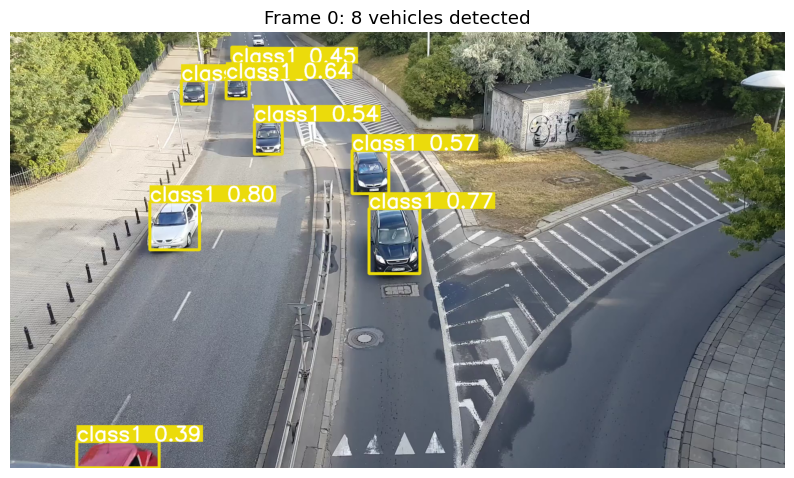

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

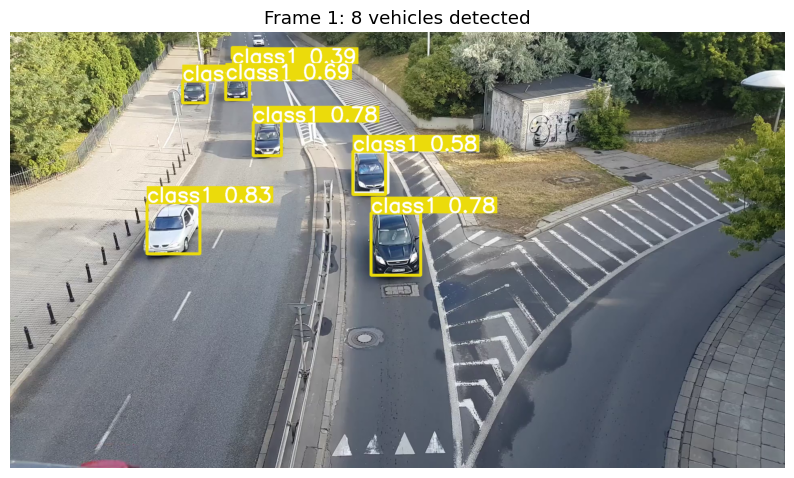

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

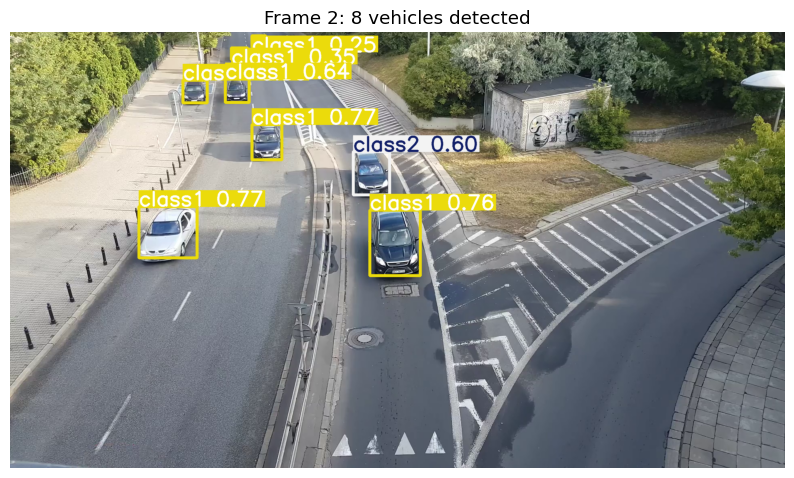

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

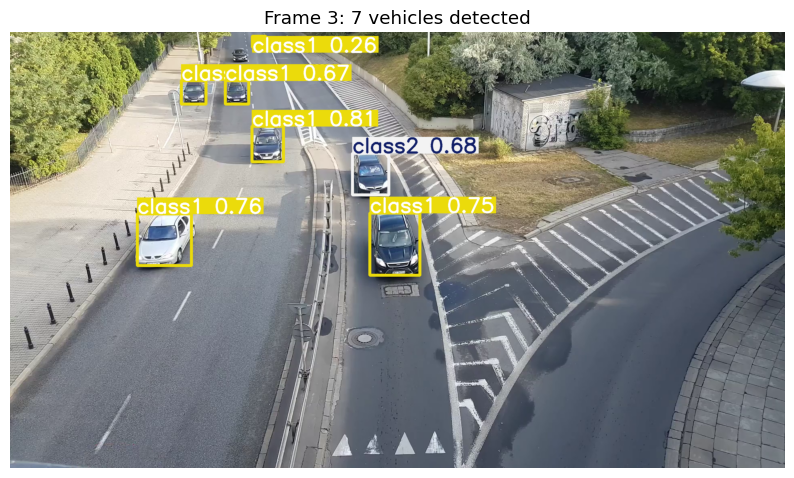

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

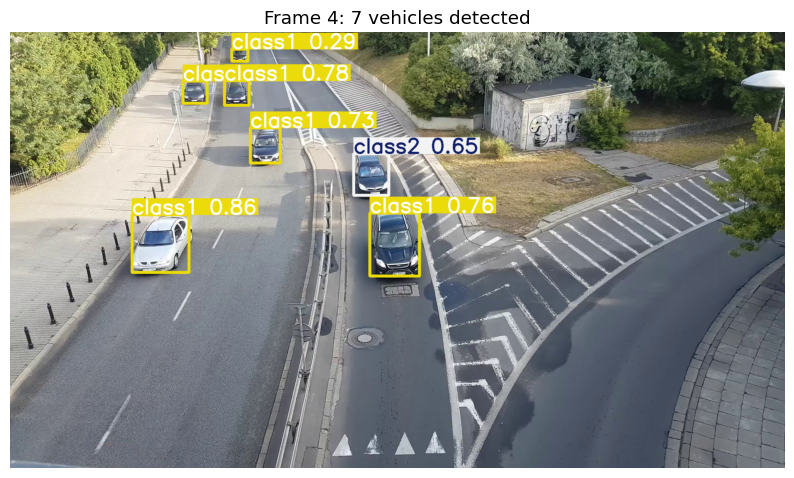

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

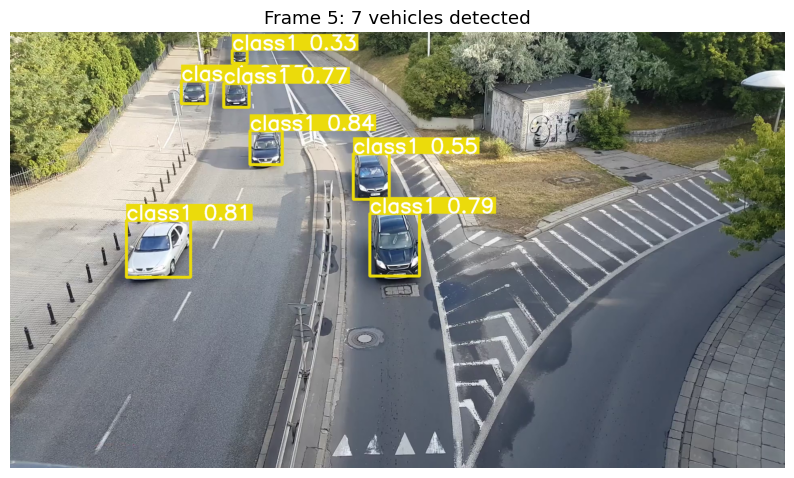

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

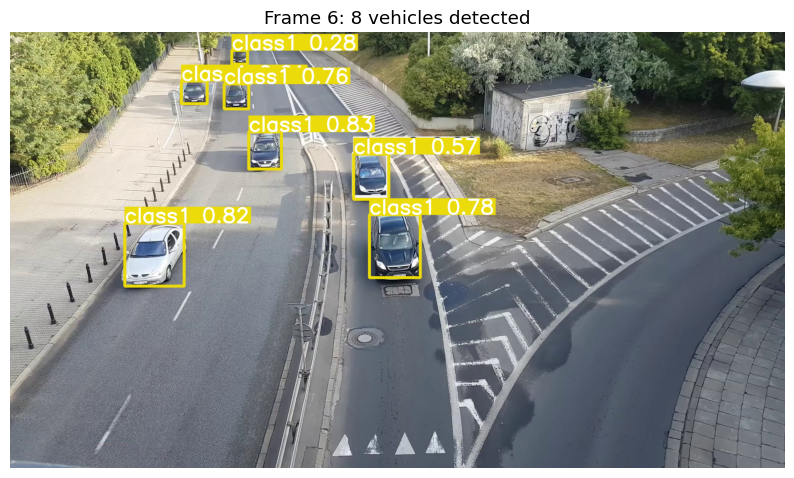

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

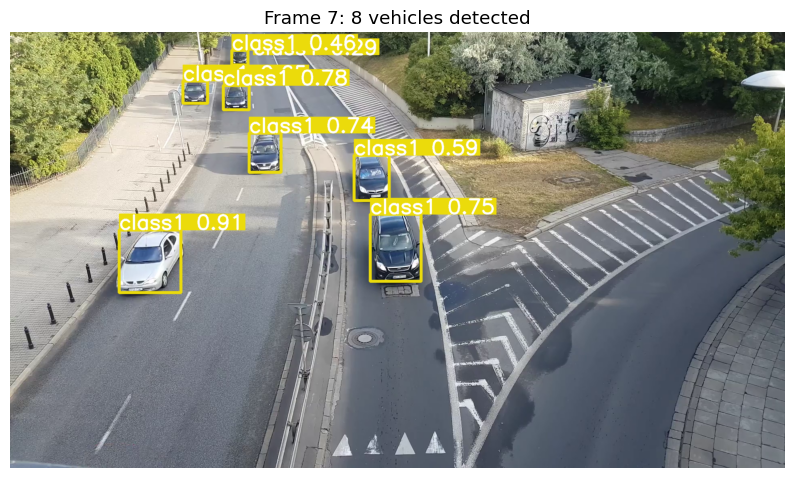

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

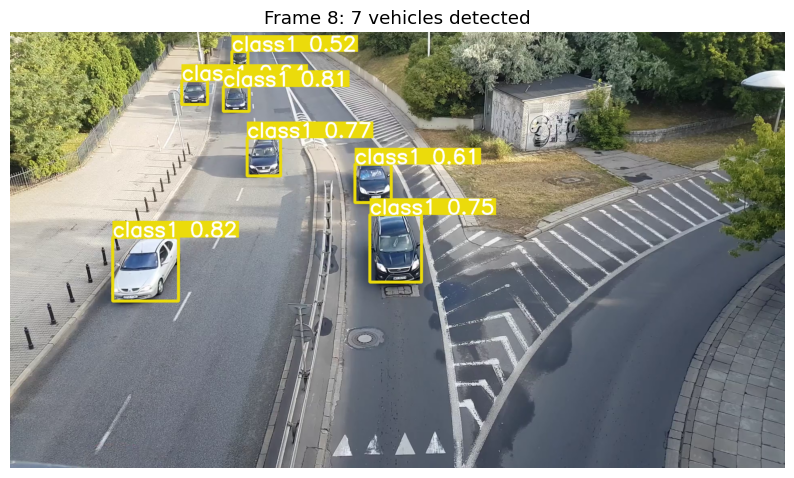

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


<Figure size 640x480 with 0 Axes>

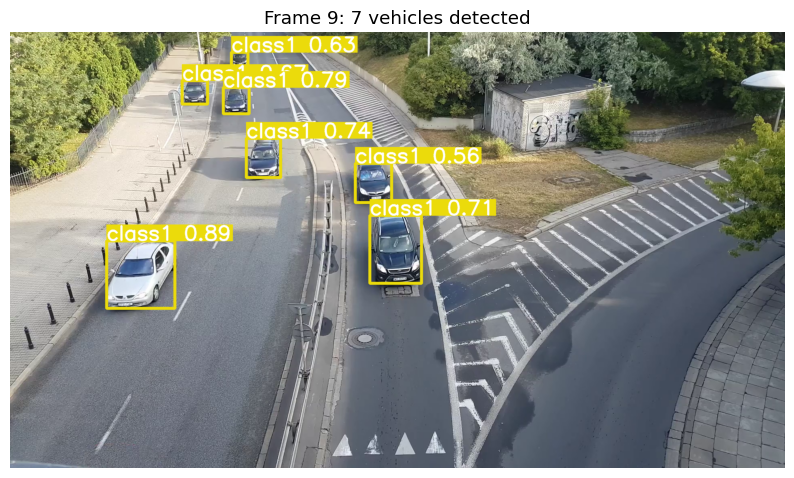

Total vehicles detected: 75


<Figure size 640x480 with 0 Axes>

In [10]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Ensure matplotlib works in the notebook
%matplotlib inline

# Load the trained model
model = torch.hub.load('ultralytics/yolov5', 'custom', path='/kaggle/working/yolov5/runs/train/exp2/weights/best.pt')

# Define the path to the video
video_path = '/kaggle/input/videotraffic/Traffic.mp4'  # Replace with your video path

# Open the video file
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

frame_count = 0
total_vehicles = 0  # Initialize total vehicle counter

while True:
    ret, frame = cap.read()
    if not ret:
        print("End of video.")
        break
    
    # Perform inference
    results = model(frame)
    
    # Get the number of vehicles detected in the current frame
    vehicle_count = len(results.xyxy[0])
    total_vehicles += vehicle_count  # Update the total vehicle count
    
    # Convert BGR to RGB for matplotlib display
    img = cv2.cvtColor(np.squeeze(results.render()), cv2.COLOR_BGR2RGB)

    # Display the frame with YOLOv5 detections
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(f"Frame {frame_count}: {vehicle_count} vehicles detected")
    plt.axis('off')
    plt.show()  # Ensure the plot is shown

    # Clear the plot to avoid overlap in subsequent iterations
    plt.clf()
    
    frame_count += 1
    if frame_count >= 10:  # Display first 10 frames for example
        break

cap.release()

# Print the total number of vehicles detected across all frames
print(f"Total vehicles detected: {total_vehicles}")


# **Example Code to Simulate Traffic Signal Management:**

In [ ]:
import torch
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

# Simulate traffic signals for 4 roads
traffic_signals = {
    'road_1': {'vehicles': 0, 'signal': 'RED'},
    'road_2': {'vehicles': 0, 'signal': 'RED'},
    'road_3': {'vehicles': 0, 'signal': 'RED'},
    'road_4': {'vehicles': 0, 'signal': 'RED'}
}

# Function to update traffic lights based on vehicle count
def update_traffic_signals():
    print("\nUpdating Traffic Signals...")
    # Sort roads by vehicle count (most to least vehicles)
    sorted_roads = sorted(traffic_signals, key=lambda x: traffic_signals[x]['vehicles'], reverse=True)
    
    # Set the first road with the most vehicles to green, others to red
    for road in traffic_signals:
        if road == sorted_roads[0]:
            traffic_signals[road]['signal'] = 'GREEN'
        else:
            traffic_signals[road]['signal'] = 'RED'
    
    print("Traffic Signal Update:")
    for road, info in traffic_signals.items():
        print(f"  {road}: Signal = {info['signal']}, Vehicles = {info['vehicles']}")

# Load the trained model
print("Loading YOLOv5 model...")
model = torch.hub.load('ultralytics/yolov5', 'custom', path='/kaggle/working/yolov5/runs/train/exp2/weights/best.pt')
print("Model loaded successfully!")

# Simulate each road with its own video feed
video_paths = {
    'road_1': '/kaggle/input/videotraffic/Traffic.mp4',
    'road_2': '/kaggle/input/videotraffic/Traffic2.mp4',
    'road_3': '/kaggle/input/videotraffic/Traffic3.mp4',
    'road_4': '/kaggle/input/videotraffic/Traffic4.mp4'
}

# Initialize video captures
caps = {road: cv2.VideoCapture(path) for road, path in video_paths.items()}

# Function to skip frames based on the video FPS and the required skip time (3 seconds)
def skip_frames(caps, skip_time):
    for road, cap in caps.items():
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        skip_frames = int(fps * skip_time)
        for _ in range(skip_frames):
            cap.grab()

# Process video frames
skip_time = 3  # Skip 3 seconds of video
iterations = 10  # Number of iterations

for iteration in range(iterations):
    print(f"\nIteration {iteration + 1}")
    for road, cap in caps.items():
        # Read a frame from the video feed
        ret, frame = cap.read()
        if not ret:
            print(f"  End of video for {road}")
            continue
        
        # Perform inference to detect vehicles
        print(f"  Detecting vehicles on {road}...")
        results = model(frame)
        vehicle_count = len(results.xyxy[0])
        
        # Update vehicle count for the road
        traffic_signals[road]['vehicles'] = vehicle_count
        print(f"  {road}: {vehicle_count} vehicles detected")
        
        # Render the results on the frame
        rendered_frame = results.render()[0]  # Render the bounding boxes and labels
        
        # Convert BGR frame to RGB for Matplotlib
        rendered_frame_rgb = cv2.cvtColor(rendered_frame, cv2.COLOR_BGR2RGB)
        
        # Display the frame using Matplotlib
        plt.figure(figsize=(10, 6))
        plt.imshow(rendered_frame_rgb)
        plt.title(f'{road} Frame with Detection')
        plt.axis('off')
        plt.show()
    
    # Skip frames equivalent to 3 seconds for each video
    skip_frames(caps, skip_time)
    
    # Update traffic signals based on vehicle count
    update_traffic_signals()
    
    # Introduce a delay of 1 second between each iteration
    time.sleep(1)  # Delay of 1 second before processing the next frame

# Release video captures
for cap in caps.values():
    cap.release()

print("End of program")

In [12]:
import shutil
shutil.make_archive("/kaggle/working/trafficOutputFolders", 'zip', '/kaggle/working')

'/kaggle/working/trafficOutputFolders.zip'